# Detecting Insults in Social Commentary

In [29]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Define the project root directory


In [30]:
from pathlib import Path
root = Path('/content/drive/MyDrive/Colab Notebooks/Troll-Detection')

Add the root directory to the system path so that we can import custom modules.


In [31]:
import sys
sys.path.append(root.as_posix())

Import the data.

In [32]:
import pandas as pd

train = root.joinpath('train.csv')
df = pd.read_csv(train)
df.shape

(3947, 3)

So our data has 3947 examples and 3 features.

Let's take a look at the first few examples in our dataframe.

In [33]:
df.head(10)

,Insult,Date,Comment
0,1,20120618192155Z,"""You fuck your dad."""
1,0,20120528192215Z,"""i really don't understand your point.\xa0 It ..."
2,0,NaN,"""A\\xc2\\xa0majority of Canadians can and has ..."
3,0,NaN,"""listen if you dont wanna get married to a man..."
4,0,20120619094753Z,"""C\xe1c b\u1ea1n xu\u1ed1ng \u0111\u01b0\u1edd..."
5,0,20120620171226Z,"""@SDL OK, but I would hope they'd sign him to ..."
6,0,20120503012628Z,"""Yeah and where are you now?"""
7,1,NaN,"""shut the fuck up. you and the rest of your fa..."
8,1,20120502173553Z,"""Either you are fake or extremely stupid...may..."
9,1,20120620160512Z,"""That you are an idiot who understands neither..."


In [34]:
df["Insult"].unique()

array([1, 0])

So, the column `Insult` has one of two values `0` or `1`. We want our final model to predict how likely a comment is an insult rather than binary `0` i.e. insult or `1` i.e. insult.

Also, the column `Date` has nothing to do with the type of comment a user can make so let's drop it.

In [35]:
df.drop("Date", axis=1, inplace=True)

In [36]:
df.head(3)

,Insult,Comment
0,1,"""You fuck your dad."""
1,0,"""i really don't understand your point.\xa0 It ..."
2,0,"""A\\xc2\\xa0majority of Canadians can and has ..."


In [37]:
df.shape

(3947, 2)

# Text Cleaning

In [38]:
text = df["Comment"]
print(type(text))

<class 'pandas.core.series.Series'>


## Establish a text cleaning pipeline

1. [X] Normalize
1. [X] Parse HTML with `BeautifulSoup`
1. [X] Whitespace characters
1. [X] Underscores
1. [X] Quotation marks
1. [X] Conversion to Lowercase
1. [X] Punctuations
1. [X] Unicode characters :- emoticons, non-english characters
1. [ ] Contraction handling
1. [ ] Other special characters

## Import a custom Py module with NLP utillites

In [39]:
import nlp_utils
import importlib

importlib.reload(nlp_utils)
textcleaner = nlp_utils.TextCleaner()

Let's take a look at a random example.

In [40]:
import random
random.seed(42)
random_index = random.randint(0, 2235)
random_index

456

Let's take an initial look at a random comment.

In [41]:
text = df["Comment"]
original = text
original[random_index]

'"Sorry, you are wrong again and as usual."'

This original text will go through a bunch of steps in our text cleaning pipeline.

First, normalize the text viz. includes converting all quoted and escaped literals into equivalent Py values.

In [42]:
text = text.apply(textcleaner.normalize_literal_string)
normalized = text
normalized[random_index]

'Sorry, you are wrong again and as usual.'

Fix HTML

In [43]:
from bs4 import MarkupResemblesLocatorWarning
import warnings

warnings.filterwarnings("ignore", category=MarkupResemblesLocatorWarning)

In [44]:
from bs4 import BeautifulSoup

text = text.apply(lambda t: BeautifulSoup(t, "html.parser").get_text())
htmlParsed = text
htmlParsed[random_index]

'Sorry, you are wrong again and as usual.'

Fix White Space characters

In [45]:
text = text.apply(textcleaner.FixWhiteSpace)
whiteSpacedFixed = text
whiteSpacedFixed[random_index]

'Sorry, you are wrong again and as usual.'

Remove underscores and minus characters

In [46]:
text = text.apply(textcleaner.RemoveSymbols)
symbolsRemoved = text
symbolsRemoved[random_index]

'Sorry, you are wrong again and as usual.'

Remove `"` and `'` characters entirely.

In [47]:
text = text.apply(textcleaner.RemoveQuotes)
quotesRemoved = text
quotesRemoved[random_index]

'Sorry, you are wrong again and as usual.'

Conver all characters to lowercase where possible.

In [48]:
text = text.apply(textcleaner.tolower)
lowercased = text
lowercased[random_index]

'sorry, you are wrong again and as usual.'

~~Remove~~ Tag punctuation marks to preserve semantics.

In [49]:
text = text.apply(textcleaner.TokenizePunctuationMarks)
punctuationMarksTokenized = text
punctuationMarksTokenized[random_index]

'sorry, you are wrong again and as usual.'

Fix dots?

In [50]:
text = text.apply(textcleaner.FixDots)
dotsFixed = text
dotsFixed[random_index]

'sorry, you are wrong again and as usual'

In [51]:
# Wrap everything above inside a function
def clean_text(text):
  """
  PIPELINE:

           Normalize
               ↓
           Parse HTML
               ↓
         Fix White Space
               ↓
         Remove Symbols
               ↓
         Remove Quotes
               ↓
           Lowercase
               ↓
    Tokenize Punctuation Marks
               ↓
           Fix Dots
  """
  cleaner = nlp_utils.TextCleaner()
  text = cleaner.normalize_literal_string(text)
  text = BeautifulSoup(text, "html.parser").get_text()
  text = cleaner.FixWhiteSpace(text)
  text = cleaner.RemoveSymbols(text)
  text = cleaner.RemoveQuotes(text)
  text = cleaner.tolower(text)
  text = cleaner.TokenizePunctuationMarks(text)
  text = cleaner.FixDots(text)
  return text

Now, we deal with special characters such as unicode characters.

In [52]:
def is_ascii(text):
    try:
        text.encode("ascii")
        return True
    except UnicodeEncodeError:
        return False

In [53]:
unicode_encoding_idxs = [idx for idx, t in enumerate(text) if not is_ascii(t)]
len(unicode_encoding_idxs)

64

So, there are 64 examples that contain where unicode characters are present.
Since 64 is a fairly small amount in our dataset, we can choose to drop all these examples from our data.

But first, let's have a peek into each of these examples.

In [54]:
text[unicode_encoding_idxs]

,Comment
4,các bạn xuống đường biểu tình 2011 có ôn hoà k...
52,grazie mille sabrina _X\n sei così dolce. baci
81,mátenlos _BX\n http://1.bp.blogspot.com/yvszmv...
174,"gallup daily may 2426, 2012 – updates daily at..."
278,o neil hold your ground _BX\n dont admit to s...
...,...
3722,hodgson was obviously rattled by the uproar ab...
3748,"she is as irrelevant as bush, sarkozy and the ..."
3792,“with respect to the notion that i can just su...
3861,konstigt när barca inte släpper bollen utan st...


Most of these seem to be non-english comments.

So, let's replace each of these examples with `np.nan` and we will drop these later.


In [55]:
import numpy as np

text[unicode_encoding_idxs] = np.nan
text[unicode_encoding_idxs]

,Comment
4,NaN
52,NaN
81,NaN
174,NaN
278,NaN
...,...
3722,NaN
3748,NaN
3792,NaN
3861,NaN


In [56]:
unicodeCharsRemoved = text

Now, let's log the outcome of each step in our pipeline for all of our examples.

In [137]:
from datetime import datetime

nexamples, _ = df.shape

pipeline = {
    "original"                   : original,
    "normalized"                 : normalized,
    "htmlParsed"                 : htmlParsed,
    "whiteSpacedFixed"           : whiteSpacedFixed,
    "symbolsRemoved"             : symbolsRemoved,
    "quotesRemoved"              : quotesRemoved,
    "lower cased"                : lowercased,
    "punctuationMarksTokenized"  : punctuationMarksTokenized,
    "dotsFixed"                  : dotsFixed,
    "unicodeCharRemoved"         : unicodeCharsRemoved
}

logfile = root.joinpath('cleantext.txt')

with open(logfile, 'w') as f:
    f.write(f"Logs created on {datetime.now().strftime('%Y-%m-%d')}\n\n")
    for idx in range(nexamples):
        f.write(f"[{idx}]\n\n")
        for step, outcome in pipeline.items():
            f.write(f"- {step}:\n\t{outcome[idx]!r}\n\n")

Finally, let's replace `df["Comment"]` with our cleaned text.

In [ ]:
df["Comment"] = unicodeCharsRemoved
df.head(5)

,Insult,Comment
0,1,you fuck your dad
1,0,i really dont understand your point. it seems ...
2,0,a\xc2\xa0majority of canadians can and has bee...
3,0,listen if you dont wanna get married to a man ...
4,0,NaN


In [ ]:
df.shape

(3947, 2)

# Exploratory Data Analysis

1. Check the `logs.txt` file to see the results and any shotcomings of our cleaning.
1. Modify the methods in the text cleaning pipeline as necessary and rerun the cleaning pipeline.
1. Proceed to additional EDA

Now, let's drop the examples where the `Comment` column holds empty strings.

In [ ]:
df = df.dropna()

In [ ]:
df.shape

(3883, 2)

In [ ]:
df.head(10)

,Insult,Comment
0,1,you fuck your dad
1,0,i really dont understand your point. it seems ...
2,0,a\xc2\xa0majority of canadians can and has bee...
3,0,listen if you dont wanna get married to a man ...
5,0,"@sdl ok, but i would hope theyd sign him to a ..."
6,0,yeah and where are you now _Q
7,1,shut the fuck up. you and the rest of your fag...
8,1,either you are fake or extremely stupid _SS\nm...
9,1,that you are an idiot who understands neither ...
10,0,@jdstorm dont wish him injury but it happened ...


Notice, when we drop the columns the indexes are preserved. This is normal pandas behaviour.

Separate the Features X and labels y.

In [ ]:
df.head(3)

,Insult,Comment
0,1,you fuck your dad
1,0,i really dont understand your point. it seems ...
2,0,a\xc2\xa0majority of canadians can and has bee...


# Tokenization

In [ ]:
import nltk

Let's download all the necessary NLTK packages at the same time.

In [ ]:
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('brown')
nltk.download('treebank')
nltk.download('wordnet')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package brown to /root/nltk_data...
[nltk_data]   Unzipping corpora/brown.zip.
[nltk_data] Downloading package treebank to /root/nltk_data...
[nltk_data]   Unzipping corpora/treebank.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [ ]:
from nltk import word_tokenize
import re

def SplitAndTokenize(sequence):
    """
    Splits a comment into phrases by delimiters, then tokenizes each phrase.
    e.g. "A quick brown fox\njumps over the lazy dog" becomes
    [['A', 'quick', 'brown', 'fox'], ['jumps', 'over', 'the', 'lazy', 'dog']]
    """
    delimiters = r'[;:\.()\n]'
    phrases = re.split(delimiters, sequence)
    tokens = [word_tokenize(phrase) for phrase in phrases]
    return tokens


def getCleanedAndSplit(value, identifier="id"):
    comment = df[df[identifier] == value]["Comment"]
    for item in comment.iloc[0]:
        print(item)

In [ ]:
split_and_tokenized_comments = df["Comment"].apply(SplitAndTokenize)

In [ ]:
df["Comment"] = split_and_tokenized_comments

In [ ]:
df.head(3)

,Insult,Comment
0,1,"[[you, fuck, your, dad]]"
1,0,"[[i, really, dont, understand, your, point], [..."
2,0,"[[a\xc2\xa0majority, of, canadians, can, and, ..."


Our data is cleaned and tokenized at this point, the next step is tagging and categorizing our data i.e. Lingusitc preparation.

# Feature Extraction

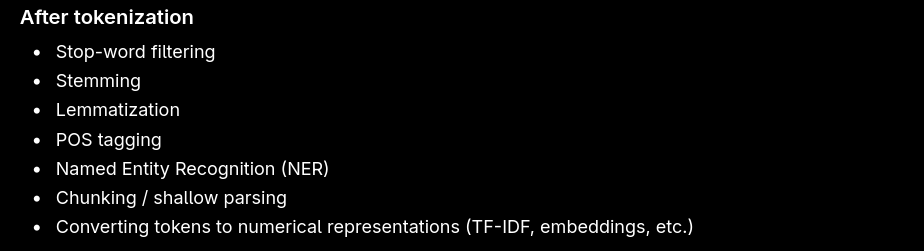

Let's build a words array of all the words in our data.

In [ ]:
import itertools

phrases = itertools.chain.from_iterable(split_and_tokenized_comments)
words = itertools.chain.from_iterable(phrases)
words = list(words)
len(words)

135744

## Stop Word Filtering

In [ ]:
from nltk.corpus import stopwords

english_stopwords = set(stopwords.words("english"))
len(english_stopwords)

198

So, there are 198 stopwords. Let's filter our data.

For each comment there can be one or more phrases.

So, the pseudocode for this step is


```
for each phrase in a comment
  remove stop words from the phrase
  return the phrase with no stop words
```

In [ ]:
def RemoveStopWords(sequence):
  return [word for word in sequence if word not in english_stopwords]

In [ ]:
comment_no_stopwords = df["Comment"].apply(lambda phrases:
  [RemoveStopWords(phrase)  for phrase in phrases])

comment_no_stopwords = comment_no_stopwords.apply(lambda x: list(itertools.chain.from_iterable(x)))
df["Comment No Stopwords"] = comment_no_stopwords

In [ ]:
df.head(5)

,Insult,Comment,Comment No Stopwords
0,1,"[[you, fuck, your, dad]]","[fuck, dad]"
1,0,"[[i, really, dont, understand, your, point], [...","[really, dont, understand, point, seems, mixin..."
2,0,"[[a\xc2\xa0majority, of, canadians, can, and, ...","[a\xc2\xa0majority, canadians, wrong, \n\nunle..."
3,0,"[[listen, if, you, dont, wan, na, get, married...","[listen, dont, wan, na, get, married, man, wom..."
5,0,"[[@, sdl, ok, ,, but, i, would, hope, theyd, s...","[@, sdl, ok, ,, would, hope, theyd, sign, oney..."


##  POS Tagging and Cateogrizing Words

In [ ]:
from nltk.corpus import brown, treebank
train_data = brown.tagged_sents() + treebank.tagged_sents()

Let's check the length of our traning data.

In [ ]:
len(train_data)

61254

So, we have 61,254 ~words~ sentences to train our tagger.

In [ ]:
from nltk.tag import UnigramTagger, BigramTagger, TrigramTagger


unigram_tagger = UnigramTagger(train_data)
bigram_tagger = BigramTagger(train_data, backoff=unigram_tagger)
trigram_tagger = TrigramTagger(train_data, backoff=bigram_tagger)

In [ ]:
tagged = comment_no_stopwords.apply(lambda sequence: trigram_tagger.tag(sequence))
df["Tagged"] = tagged

In [ ]:
df.head(3)

,Insult,Comment,Comment No Stopwords,Tagged
0,1,"[[you, fuck, your, dad]]","[fuck, dad]","[(fuck, VB), (dad, NN)]"
1,0,"[[i, really, dont, understand, your, point], [...","[really, dont, understand, point, seems, mixin...","[(really, RB), (dont, None), (understand, VB),..."
2,0,"[[a\xc2\xa0majority, of, canadians, can, and, ...","[a\xc2\xa0majority, canadians, wrong, \n\nunle...","[(a\xc2\xa0majority, None), (canadians, None),..."


## POS Tags and their Meanings


In [ ]:
tags = list([tag for sequence in tagged for  _, tag in sequence])
unique_tags = set(tags)
print(f"{len(tags)} words tagged with {len(unique_tags)} unique tags.")

77919 words tagged with 91 unique tags.


Let's visiualize the distribution of the tags in our data.

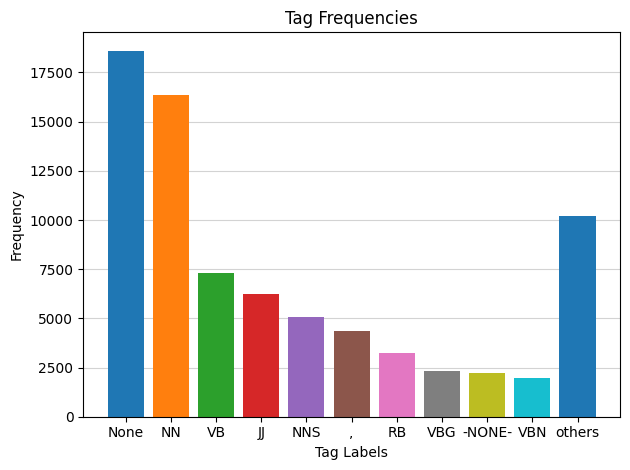

In [ ]:
from collections import Counter
from matplotlib import pyplot as plt

frequency = Counter(str(label) for label in tags)
sorted_freq = dict(sorted(frequency.items(), key=lambda x: x[1], reverse=True))

top10 = dict(list(sorted_freq.items())[:10])
others_sum = sum(list(sorted_freq.values())[10:])
if others_sum > 0:
    top10['others'] = others_sum

plt.bar(x=top10.keys(), height=top10.values(),
        color=plt.cm.tab10.colors[:len(top10)])
plt.xlabel('Tag Labels')
plt.ylabel('Frequency')
plt.title('Tag Frequencies')
plt.tight_layout()
plt.grid(axis='y', color='lightgray')
plt.gca().set_axisbelow(True)
plt.show()

Nouns
- **NN**: Noun, singular or mass (e.g., *table*, *water*)
- **NNS**: Noun, plural (e.g., *tables*, *waters*)
- **NNP**: Proper noun, singular (e.g., *John*, *London*)
- **NNPS**: Proper noun, plural (e.g., *Americans*, *Caesars*)

Verbs
- **VB**: Base form (e.g., *eat*, *go*)
- **VBD**: Past tense (e.g., *ate*, *went*)
- **VBG**: Gerund / present participle (e.g., *eating*, *going*)
- **VBN**: Past participle (e.g., *eaten*, *gone*)
- **VBP**: Non-3rd person singular present (e.g., *eat*, *go*)
- **VBZ**: 3rd person singular present (e.g., *eats*, *goes*)

Adjectives
- **JJ**: Adjective (e.g., *big*, *red*)
- **JJR**: Comparative adjective (e.g., *bigger*, *redder*)
- **JJS**: Superlative adjective (e.g., *biggest*, *reddest*)

Adverbs
- **RB**: Adverb (e.g., *quickly*, *very*)
- **RBR**: Comparative adverb (e.g., *quicker*, *further*)
- **RBS**: Superlative adverb (e.g., *quickest*, *furthest*)

Function Words
- **IN**: Preposition / subordinating conjunction (e.g., *in*, *of*, *before*)
- **DT**: Determiner (e.g., *the*, *a*, *this*)
- **PRP**: Personal pronoun (e.g., *I*, *he*, *she*)
- **PRP$**: Possessive pronoun (e.g., *my*, *his*, *her*)
- **CC**: Coordinating conjunction (e.g., *and*, *but*, *or*)
- **MD**: Modal verb (e.g., *can*, *should*, *will*)
- **TO**: Infinitive marker (e.g., *to* in *to go*)

Numbers & Special Tokens
- **CD**: Cardinal number (e.g., *one*, *two*, *first*)
- **EX**: Existential *there* (e.g., *there is*, *there are*)
- **POS**: Possessive ending (e.g., *'s*)
- **RP**: Particle (e.g., *up*, *off*)

Wh-Words
- **WDT**: Wh-determiner (e.g., *which*, *what*)
- **WP**: Wh-pronoun (e.g., *who*, *whom*)
- **WP$**: Possessive wh-pronoun (e.g., *whose*)
- **WRB**: Wh-adverb (e.g., *where*, *when*, *why*)

Other Tags
- **UH**: Interjection (e.g., *oh*, *yes*, *no*)
- **FW**: Foreign word
- **LS**: List item marker
- **. , ! ?**: Punctuation marks
- **None**: No tag assigned (unknown or unrecognized token)

## Lemmatization

Words -> lemma.

In [ ]:
from nltk import WordNetLemmatizer as wnl

lemmatizer = wnl()

In section [Present POS Tags, their distribution in the data and their Meanings]() we saw our data tagged with 73 unique tags.



In [ ]:
try:
  lemmatizer.lemmatize('dancing', pos='VBG')
except KeyError as e:
  print(f"{e}: {e.__doc__}")

'VBG': Mapping key not found.


The `wnl().lemmaztize` does not recgonize these pos tags generated by our tagger. We need to map each into `nvars` othewise we may get a `KeyError` Exception.



In [ ]:
print(unique_tags)

{'FW-IN+AT-TL', 'VBN', 'FW-AT', 'PN', None, 'MD+HV', 'PPO', 'FW-*', 'NN-NC', 'JJS', 'JJ-HL', 'NP', 'PPSS', 'CC', 'CD', 'QL', 'AT', 'WP$', 'IN-NC', 'PP$', 'FW-JJ', 'FW-UH', 'PP$$', 'JJ', 'OD-TL', 'RB', 'WDT', 'VB', 'JJT', 'OD', 'NR', 'FW-RB', 'NP-TL', 'QLP', 'FW-PPL', 'CS', ')', 'RP+IN', 'MD', 'DTX', 'VBZ', '$', '.', 'AP-HL', 'FW-AT-TL', 'VBG-HL', 'RBT', 'WRB', 'UH', '(', 'NN-HL', 'JJR', '``', 'DTI', 'NNP', 'ABN', 'FW-CC', 'FW-WDT', 'RBR', ',', 'DO', 'FW-NNS', 'NNS', 'RN', 'VBD', ',-HL', 'NN', '#', 'VBN-HL', 'AP', 'VBP', 'IN', '*', 'DT', 'CD-TL', 'NNS-HL', '-NONE-', 'VBG', 'CD-HL', 'RB-NC', 'RP', 'VB-NC', 'FW', 'FW-IN-TL', 'FW-NN', 'LS', 'FW-IN', 'JJ-NC', 'FW-PP$', 'WPS', 'FW-IN+AT'}


In [ ]:
def map_pos_tag_to_simplified(tag):
    """
    Maps a given NLTK POS tag to one of five simplified categories:
    'n' (noun), 'v' (verb), 'a' (adjective), 'r' (adverb),
    's' (satellite adjective). Any unmapped tag, including None,
    defaults to 'n'.
    """
    tag_str = str(tag).upper()

    # Nouns and noun-like tags
    if tag_str.startswith(('NN', 'FW-NN', 'PN', 'PPO', 'PP$', 'PPSS',
                           'EX', 'CD', 'WDT', 'WP', 'WPS')):
        return 'n'
    # Verbs and verb-like tags
    elif tag_str.startswith(('VB', 'FW-VB', 'MD')):
        return 'v'
    # Adjectives and adjective-like tags
    elif tag_str.startswith(('JJ', 'FW-JJ')):
        return 'a'
    # Adverbs and adverb-like tags
    elif tag_str.startswith(('RB', 'FW-RB', 'WRB', 'QL')):
        return 'r'
    # Satellite adjectives (AP: attributive adjective, predicative adjective)
    elif tag_str.startswith('AP'):
        return 's'

    # Fallback (punctuation, determiners, conjunctions, etc.)
    # As per the user's rule for 'None' to 'n', these also default to 'n'
    elif tag_str in (',', '.', '!', '?', ';', ':', '(', ')', '``', "''",
                     '#', '$', 'SYM', 'LS', 'FW', 'BEG', 'DTX', 'NR', 'OD',
                     'RP+IN', 'FW-*', 'FW-PPO', 'FW-AT', 'FW-NNS', 'AT', 'CC',
                     'FW-CC-TL', 'FW-IN', 'FW-IN-TL', 'FW-IN+AT-TL', 'IN',
                     'TO', 'RP', 'UH', 'DT', '-NONE-'):
        return 'n'

    # Default for any other unhandled tag, aligning with the 'None' rule
    return 'n'

# Create a dictionary for the mapping of all unique tags observed
pos_tag_simplified_map = {tag: map_pos_tag_to_simplified(tag) for tag in unique_tags}

# Apply the mapping to the 'Tagged' column to create 'Simplified_POS_Tags'
# Each item in 'Tagged' is a list of (word, original_tag) tuples
simplified_tagged_comments = df["Tagged"].apply(lambda tagged_list:
    [(word, pos_tag_simplified_map.get(tag, 'n')) for word, tag in tagged_list])

df["Simplified_POS_Tags"] = simplified_tagged_comments

# Display a sample of the created mapping
print("Mapping of original POS tags to simplified categories (sample of 10):")
for tag, simplified_tag in list(pos_tag_simplified_map.items())[:10]:
    print(f"  '{tag}' -> '{simplified_tag}'")

Mapping of original POS tags to simplified categories (sample of 10):
  'FW-IN+AT-TL' -> 'n'
  'VBN' -> 'v'
  'FW-AT' -> 'n'
  'PN' -> 'n'
  'None' -> 'n'
  'MD+HV' -> 'v'
  'PPO' -> 'n'
  'FW-*' -> 'n'
  'NN-NC' -> 'n'
  'JJS' -> 'a'


So, now we will use the `(token, pos)` from the `Simplified_POS_Tags` column to
lemmatize our data.

In [ ]:
def lemmatize(sequence):
  return [lemmatizer.lemmatize(token, pos=pos) for token, pos in sequence]

In [ ]:
df['Lemmatized'] = df['Simplified_POS_Tags'].apply(lambda s: lemmatize(s))

In [ ]:
df.head(3)

,Insult,Comment,Comment No Stopwords,Tagged,Simplified_POS_Tags,Lemmatized
0,1,"[[you, fuck, your, dad]]","[fuck, dad]","[(fuck, VB), (dad, NN)]","[(fuck, v), (dad, n)]","[fuck, dad]"
1,0,"[[i, really, dont, understand, your, point], [...","[really, dont, understand, point, seems, mixin...","[(really, RB), (dont, None), (understand, VB),...","[(really, r), (dont, n), (understand, v), (poi...","[really, dont, understand, point, seem, mix, a..."
2,0,"[[a\xc2\xa0majority, of, canadians, can, and, ...","[a\xc2\xa0majority, canadians, wrong, \n\nunle...","[(a\xc2\xa0majority, None), (canadians, None),...","[(a\xc2\xa0majority, n), (canadians, n), (wron...","[a\xc2\xa0majority, canadian, wrong, \n\nunles..."


This cooncludes the pre-processing of our text data.

# Vectorization

## Term Frequency-Inverse Document Frequency

Let's generate embeddings for our data.

For this we'll use TF-IDF

In [ ]:
df.shape

(3883, 6)

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer(analyzer='word',
                             lowercase=False,
                             tokenizer=None,
                             preprocessor=None,
                             stop_words=None,
                             max_features=5000)

In [ ]:
# Transform the linguistic data into numerical representations
# For each example, get 5000 features
documents = df['Lemmatized'].apply(lambda sequence: ' '.join(sequence))
vectorizer = vectorizer.fit(documents)
training_features = vectorizer.transform(documents)

In [ ]:
print(type(training_features))

<class 'scipy.sparse._csr.csr_matrix'>


In [ ]:
X = training_features.toarray()
X.shape

(3883, 5000)

We have almost 4000 examples and 5000 features.


These 5000 features are the "most important" in regard to "TF-IDF"

In [ ]:
y = df['Insult'].values
y.shape

(3883,)

Instead of a binary classifier that produces `insult` or `not insult`, rather a
continous prediction that predicts % insult is desired.

So, let's train a regressor model.

# Establish a Baseline

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np

# Train Random Forest
baseline = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42,
)

In [ ]:
# Train the baseline model
baseline.fit(X, y)

RandomForestRegressor(max_depth=10, random_state=42)

# Model Assesment

Let's define some functions that will make model assessment easy.

In [ ]:
from nltk import WordNetLemmatizer as wnl

# Wrap everything above inside a function
def clean_text(text):
  cleaner = nlp_utils.TextCleaner()
  text = cleaner.normalize_literal_string(text)
  text = BeautifulSoup(text, "html.parser").get_text()
  text = cleaner.FixWhiteSpace(text)
  text = cleaner.RemoveSymbols(text)
  text = cleaner.RemoveQuotes(text)
  text = cleaner.tolower(text)
  text = cleaner.TokenizePunctuationMarks(text)
  text = cleaner.FixDots(text)
  return text

def get_troll_score(user_input, model, vectorizer):
  user_input_cleaned = clean_text(user_input)
  # Lemmatize
  lemmatizer = wnl()
  lemmatized = [lemmatizer.lemmatize(word.lower())
                for word in user_input_cleaned.split()]
  # Vectorize using the SAME vectorizer
  user_vector = vectorizer.transform([' '.join(lemmatized)])
  score = model.predict(user_vector)[0]

  return round(score, 2)

Import the examples in the test set.

In [ ]:
test = pd.read_csv(root.joinpath('impermium_verification_labels.csv'))
test.head(3)

,id,Insult,Date,Comment,Usage
0,1,0,20120603163526Z,"""like this if you are a tribe fan""",PrivateTest
1,2,1,20120531215447Z,"""you're idiot.......................""",PrivateTest
2,3,1,20120823164228Z,"""I am a woman Babs, and the only ""war on women...",PrivateTest


In [ ]:
y_true = test['Insult'].values
y_true.shape

(2235,)

In [ ]:
tests = test['Comment']

In [ ]:
scores = tests.apply(lambda x: get_troll_score(x, baseline, vectorizer))
scores = scores.values

In [ ]:
test['Score'] = scores
test.head(3)

,id,Insult,Date,Comment,Usage,Prediction,Score
0,1,0,20120603163526Z,"""like this if you are a tribe fan""",PrivateTest,0,0.17
1,2,1,20120531215447Z,"""you're idiot.......................""",PrivateTest,1,0.97
2,3,1,20120823164228Z,"""I am a woman Babs, and the only ""war on women...",PrivateTest,0,0.37


A score of 0.17 means there is a 17% chance a comment is an insult. Likewise, 0.97 means 97% chance it is an insult.

Cut-off @ 40%

In [ ]:
cutoff = 0.40
prediction = test['Score'].apply(lambda x: 1 if x > cutoff else 0)
y_pred = prediction.values

In [ ]:
test[f'Prediction {cutoff}'] = prediction
test.head(3)

,id,Insult,Date,Comment,Usage,Prediction,Score,Prediction 0.4
0,1,0,20120603163526Z,"""like this if you are a tribe fan""",PrivateTest,0,0.17,0
1,2,1,20120531215447Z,"""you're idiot.......................""",PrivateTest,1,0.97,1
2,3,1,20120823164228Z,"""I am a woman Babs, and the only ""war on women...",PrivateTest,0,0.37,0


Let's generate a confusion matrix.

In [ ]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_true, y_pred)

array([[1107,   51],
       [ 752,  325]])

```
[[TN FP]
 [FN TP]]
```

The number of FN is higher while TP is relatively low. So although the model
seems to predict `not insults` quite well and actually struggles to predict
`insults`.

 The scoring seems to capture direct insults well, but struggles with context and intent. The high baseline (0.17) might be inflating all scores, making it harder to meaningfully differentiate lower-level toxicity from higher-level attacks.

Let's define some metrics.

In [ ]:
from sklearn.metrics import f1_score, roc_curve, auc
print("f1:", f1_score(y_true, y_pred))

f1: 0.4473503097040606


In [ ]:
fpr, tpr, _ = roc_curve(y_true, scores)
roc_auc = auc(fpr, tpr)
print("Random Forest benchmark AUC score, 100 estimators")
print(roc_auc)


Random Forest benchmark AUC score, 100 estimators
0.6999012160369991


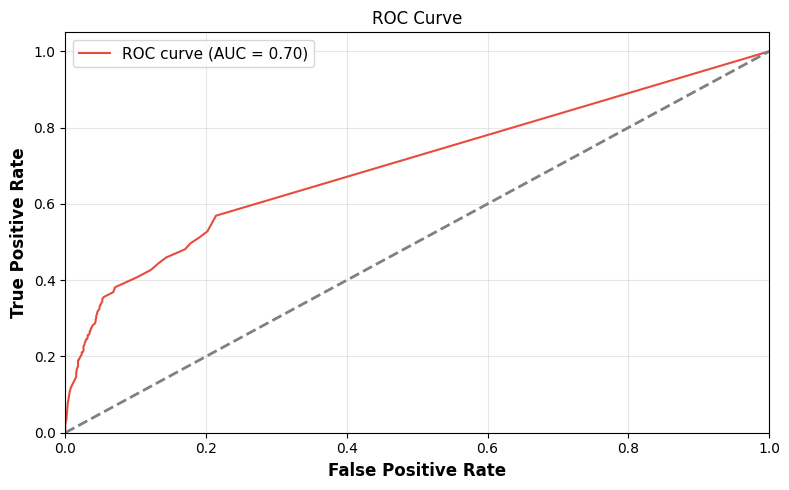

In [ ]:
# Plot
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(fpr, tpr, color='#e74c3c', label=f'ROC curve (AUC = {roc_auc:.2f})')
ax.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')

ax.set_xlim(0.0, 1.0)
ax.set_ylim(0.0, 1.05)
ax.set_xlabel('False Positive Rate', fontsize=12, fontweight='bold')
ax.set_ylabel('True Positive Rate', fontsize=12, fontweight='bold')
ax.set_title('ROC Curve')
ax.legend(loc='best', fontsize=11)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()